# LAB ASSESMENT Machine Learning


**   **
**Name: Ghrushnesh Sudhakar Patil**

**Class: CSAI-D**     

**Batch : 3**

**Roll No: 66**

**PRN: 12411658**

**   **

Q15.

Extra Work Implementing LOGESTIC REGRESSION

In [ ]:
print(df.describe())
print(df.isnull().sum())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

# Final Implemented CODE


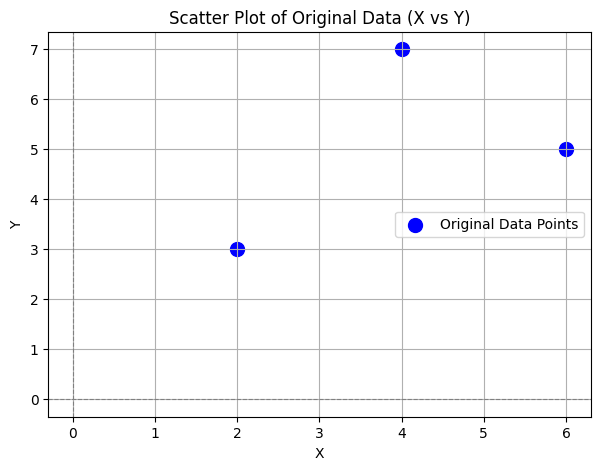

Centered Data:
 [[-2. -2.]
 [ 0.  2.]
 [ 2.  0.]]

Projected Data (First Principal Component Scores):
[-4.  2.  2.]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array([
    [2, 3],
    [4, 7],
    [6, 5]
])

X_coords = data[:, 0]
Y_coords = data[:, 1]

plt.figure(figsize=(7, 5))
plt.scatter(X_coords, Y_coords, color='blue', s=100, label='Original Data Points')
plt.title('Scatter Plot of Original Data (X vs Y)')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.show()

mean = np.mean(data, axis=0)
centered_data = data - mean

print("Centered Data:\n", centered_data)

principal_component_1_eigenvector = np.array([1, 1])

projected_data_pc1 = centered_data @ principal_component_1_eigenvector

print("\nProjected Data (First Principal Component Scores):")
print(projected_data_pc1)

In [ ]:
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[col] = df[col].replace(0, df[col].mean())

print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.681605      72.254807      26.606479  118.660163   
std       3.369578   30.436016      12.115932       9.631241   93.080358   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      20.536458   79.799479   
50%       3.000000  117.000000      72.000000      23.000000   79.799479   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.450805                  0.471876   33.240885    0.348958  
std      6.875374                  0.331329   11.760232    0.476951  
min     18.200000                  

Now that the data is cleaned, let's perform Logistic Regression.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.7662
Precision: 0.6863
Recall: 0.6364
F1-Score: 0.6604
Confusion Matrix:
 [[83 16]
 [20 35]]
